In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_parquet("../../data/heart attack/heart_attack_youth_vs_adult.parquet")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 20 columns):
 #   Column               Dtype  
---  ------               -----  
 0   ID                   int64  
 1   Age_Group            int64  
 2   Gender               int64  
 3   Ethnicity            int64  
 4   Smoking_Status       int64  
 5   Alcohol_Consumption  float64
 6   Diet_Quality         int64  
 7   Cholesterol_Level    int64  
 8   Blood_Pressure       int64  
 9   BMI                  float64
 10  Physical_Activity    int64  
 11  Stress_Level         int64  
 12  Family_History       int64  
 13  Diabetes             int64  
 14  Air_Quality_Index    int64  
 15  Income_Level         int64  
 16  Sleep_Hours          float64
 17  Heart_Rate           int64  
 18  Medication_Status    int64  
 19  Heart_Attack         int64  
dtypes: float64(3), int64(17)
memory usage: 762.9 MB


In [5]:
df.shape

(5000000, 20)

In [6]:
df.Heart_Attack.value_counts()[0]/df.Heart_Attack.value_counts()[1]

8.994403134244823

In [7]:
df[df.columns[df.isnull().sum()>0]].isnull().sum()

Alcohol_Consumption    1998915
dtype: int64

In [8]:
df.Alcohol_Consumption.value_counts()

Alcohol_Consumption
0.0    2501560
1.0     499525
Name: count, dtype: int64

In [9]:
df.Alcohol_Consumption.value_counts().sum() - df.shape[0]

-1998915

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.svm import LinearSVC
from scipy.stats import loguniform

# x = df.dropna(axis=0)
# x = x.drop('Alcohol_Consumption', axis=1)
# x = x.sample(10000)
# y = df.dropna(axis=0)
# y = y['Alcohol_Consumption']
# y = y.sample(10000)
# print(y.value_counts())
# print(y.value_counts()[0]/y.value_counts()[1])

# x_null = df[df.Alcohol_Consumption.isnull()]
# x_null = x_null.drop('Alcohol_Consumption', axis=1)


# params = {
    
#     'n_estimators':[100, 200, 300, 500],
#     'max_depth':[None, 3, 5, 7, 10],
#     'min_samples_split':[2, 3, 5, 7],
#     'min_samples_leaf':[1, 2, 3, 4, 5],
#     'bootstrap':[True, False],
    
# }

# rf_model = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=params, n_iter=10, cv=3, scoring='accuracy', verbose=1)
# rf_model.fit(x,y)

# svm_params = {
    
#     'C':loguniform(1e-4, 100),
#     'penalty':['l1', 'l2'],
#     # 'dual':[False, True],
#     'loss':['squared_hinge'],
#     'class_weight':[None, {0:1, 1:3}, {0:1, 1:5},'balanced'],
    
# }
# svm_model = LinearSVC(max_iter=10000, random_state=42)
# grid_svm = RandomizedSearchCV(estimator=svm_model, param_distributions=svm_params, cv=3, n_iter=30, random_state=42, scoring='accuracy', verbose=1)
# grid_svm.fit(x, y)


# rf_model.best_score_

# df.loc[df['Alcohol_Consumption'].isnull(), 'Alcohol_Consumption'] = rf_model.predict(x_null)

# df.Alcohol_Consumption.value_counts()

### tried both model all are predicting 0 with thier trainig score 84%

In [11]:
df.Alcohol_Consumption = df.Alcohol_Consumption.fillna(0, axis=0)

In [12]:
df.isnull().sum()

ID                     0
Age_Group              0
Gender                 0
Ethnicity              0
Smoking_Status         0
Alcohol_Consumption    0
Diet_Quality           0
Cholesterol_Level      0
Blood_Pressure         0
BMI                    0
Physical_Activity      0
Stress_Level           0
Family_History         0
Diabetes               0
Air_Quality_Index      0
Income_Level           0
Sleep_Hours            0
Heart_Rate             0
Medication_Status      0
Heart_Attack           0
dtype: int64

In [13]:
df.Heart_Attack.value_counts()

Heart_Attack
0    4499720
1     500280
Name: count, dtype: int64

In [14]:
df.Heart_Attack.value_counts()[0]/df.Heart_Attack.value_counts()[1]

8.994403134244823

In [15]:
x = df.drop('Heart_Attack', axis=1)
y = df['Heart_Attack']
svm_params = {
    
    'C':loguniform(1e-4, 50),
    'class_weight':[{0:1, 1:9}, {0:1, 1:8}, {0:1, 1:10}],
    
}
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, stratify=y, random_state=42)
svm_model = LinearSVC(max_iter=10000, random_state=42)
grid_svm = RandomizedSearchCV(estimator=svm_model, param_distributions=svm_params, cv=3, n_iter=50, random_state=42, scoring='accuracy', verbose=2)
grid_svm.fit(x_train, y_train)
y_pred = grid_svm.predict(x_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END ..C=0.013629907319433754, class_weight={0: 1, 1: 9}; total time=   8.4s
[CV] END ..C=0.013629907319433754, class_weight={0: 1, 1: 9}; total time=  10.3s
[CV] END ..C=0.013629907319433754, class_weight={0: 1, 1: 9}; total time=   9.3s
[CV] END ..C=0.001110169687972236, class_weight={0: 1, 1: 9}; total time=   6.8s
[CV] END ..C=0.001110169687972236, class_weight={0: 1, 1: 9}; total time=   6.7s
[CV] END ..C=0.001110169687972236, class_weight={0: 1, 1: 9}; total time=   7.1s
[CV] END ...C=0.25201776005603743, class_weight={0: 1, 1: 8}; total time=   5.8s
[CV] END ...C=0.25201776005603743, class_weight={0: 1, 1: 8}; total time=   5.7s
[CV] END ...C=0.25201776005603743, class_weight={0: 1, 1: 8}; total time=   5.7s
[CV] END C=0.0007744762285330786, class_weight={0: 1, 1: 10}; total time=   5.7s
[CV] END C=0.0007744762285330786, class_weight={0: 1, 1: 10}; total time=   5.6s
[CV] END C=0.0007744762285330786, class_weight=

In [16]:
grid_svm.best_params_

{'C': 0.25201776005603743, 'class_weight': {0: 1, 1: 8}}

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [18]:
accuracy = accuracy_score(y_test, y_pred)

In [19]:
accuracy

0.899944

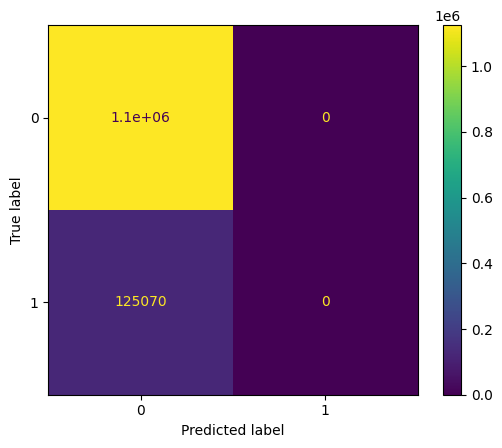

In [20]:
cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
cm.plot()

In [21]:
print(classification_report(y_test, y_pred))

/home/harsh/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/harsh/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.90      1.00      0.95   1124930
           1       0.00      0.00      0.00    125070

    accuracy                           0.90   1250000
   macro avg       0.45      0.50      0.47   1250000
weighted avg       0.81      0.90      0.85   1250000



/home/harsh/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
info = {}
info.update({'svm':{'best_params':grid_svm.best_params_, 'acc':accuracy}})

In [23]:
import json
with open("note.json", 'w') as file:
    file.write(json.dumps(info))

In [27]:

import xgboost as xgb

xgb_params = {
    
'n_estimators': [1000],               # Set high for early stopping
'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinkage
'max_depth': [None, 3, 5, 7, 10],              # Tree complexity
'subsample': [0.8, 1.0],             # Rows per tree
'colsample_bytree': [0.8, 1.0],      # Columns per tree
# 'grow_policy': ['depthwise', 'lossguide'],
# Regularization
'reg_alpha': [0, 0.1, 1],
'reg_lambda': [0.1, 1, 10],
# 'gamma': [0, 0.1, 1],
# unbalanced
'min_child_weight': [1, 5, 10],
# 'eval_metric': ['logloss', 'aucpr']  # Handle class imbalance
    
}
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
x_temp, x_val, y_temp, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
unbalanced_weight = round(y.value_counts().sort_values()[0]/y.value_counts().sort_values()[1])
xgb_model = xgb.XGBClassifier(early_stopping_rounds=10, eval_metric='aucpr', scale_pos_weight=unbalanced_weight)
grid_xgb_model = RandomizedSearchCV(estimator=xgb_model, param_distributions=xgb_params, cv=3, n_iter =20, scoring='accuracy', verbose=2)
grid_xgb_model.fit(x_temp, y_temp, eval_set=[(x_val, y_val)])


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[0]	validation_0-aucpr:0.09986
[1]	validation_0-aucpr:0.09984
[2]	validation_0-aucpr:0.10007
[3]	validation_0-aucpr:0.10011
[4]	validation_0-aucpr:0.09986
[5]	validation_0-aucpr:0.09981
[6]	validation_0-aucpr:0.09976
[7]	validation_0-aucpr:0.09979
[8]	validation_0-aucpr:0.09970
[9]	validation_0-aucpr:0.09976
[10]	validation_0-aucpr:0.09968
[11]	validation_0-aucpr:0.09971
[12]	validation_0-aucpr:0.09979
[13]	validation_0-aucpr:0.09977
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=None, min_child_weight=5, n_estimators=1000, reg_alpha=0.1, reg_lambda=0.1, subsample=1.0; total time=   6.7s
[0]	validation_0-aucpr:0.09999
[1]	validation_0-aucpr:0.10013
[2]	validation_0-aucpr:0.10014
[3]	validation_0-aucpr:0.10045
[4]	validation_0-aucpr:0.10047
[5]	validation_0-aucpr:0.10048
[6]	validation_0-aucpr:0.10057
[7]	validation_0-aucpr:0.10070
[8]	validation_0-aucpr:0.10066
[9]	validation_0-aucpr:0.10064
[10]	validation_0-auc

AttributeError: 'RandomizedSearchCV' object has no attribute 'predit'

In [29]:
y_pred = grid_xgb_model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(acc)

0.5156544


In [31]:
info.update({'xgboost':{'best_params':grid_xgb_model.best_params_, 'acc':acc}})

In [32]:
import json
with open("note.json", 'w') as file:
    file.write(json.dumps(info))

In [ ]:
classification_report(y_test, y_pred)